# Charged Black Holes in Entangled Relativity
## Arnaud Crepinge - M2 Internship

### Null Geodesics Analysis

In [1]:
# Import libraries

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp

# Font for plotting

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})

## 1 - Definitions

In [2]:
# Horizons in GR

def rpm_GR(M, Q):
    sqrt = sp.sqrt if isinstance(M, sp.Basic) else np.sqrt
    disc = sqrt(M**2 - Q**2)
    return M + disc, M - disc

# Horizons in ER

def rpm_ER(M, Q):
    disc = np.sqrt(M**2 - (11/12) * Q**2)
    return M + disc, (13/11) * (M - disc)

def rpm_ER_sym(M, Q):
    disc = sp.sqrt(M**2 - sp.Rational(11, 12) * Q**2)
    return M + disc, sp.Rational(13, 11) * (M - disc)

# Effective Potential in GR

def Veff_GR(r, M, Q):
    rp, rm = rpm_GR(M,Q)
    return (1 / r**2) * (1 - rm/r) * (1 - rp/r)

# Effective Potential in ER

def Veff_ER(r, M, Q):
    rp, rm = rpm_ER(M,Q)
    return (1 / r**2) * (1 - rp/r) * (1 - rm/r)**(9/13)

### Computing the Christoffel Symbols

In [3]:
# Coordinates & Parameters

t, r, th, ph = sp.symbols('t r theta phi', real=True, positive=True)
M, Q         = sp.symbols('M Q', real=True, positive=True)

coords  = [t, r, th, ph]
params  = [M, Q]
all_sym = coords + params

# Metric for GR -> Reissner-Nordström

rp_GR, rm_GR = rpm_GR(M,Q)
f = (1 - rm_GR/r) * (1 - rp_GR/r)

g_GR = sp.Matrix([
    [-f, 0, 0, 0],
    [0, 1/f, 0, 0],
    [0, 0, r**2, 0],
    [0, 0, 0, r**2 * sp.sin(th)**2]
])

# Metric for ER

rp_ER, rm_ER = rpm_ER_sym(M,Q)
f1 = (1 - rp_ER/r) * (1 - rm_ER/r)**sp.Rational(15, 13)
f2 = (1 - rp_ER/r) * (1 - rm_ER/r)**sp.Rational(7, 13)
f3 = (1 - rm_ER/r)**sp.Rational(6, 13)

g_ER = sp.Matrix([
    [-f1, 0, 0, 0],
    [0, 1/f2, 0, 0],
    [0, 0, r**2 * f3, 0],
    [0, 0, 0, r**2 * sp.sin(th)**2 * f3]
])

# Computing Christoffel Symbols

def compute_christoffel_sym(g, coords):
    n   = len(coords)
    g_inv = g.inv()
    
    # ∂_σ g_μν  — precomputed once
    dg = [[[sp.diff(g[m, n_], coords[s]) for s in range(n)]
            for n_ in range(n)]
           for m in range(n)]
    
    G = [[[None]*n for _ in range(n)] for _ in range(n)]
    for mu in range(n):
        for al in range(n):
            for be in range(al, n):          # exploit symmetry Γ^μ_αβ = Γ^μ_βα
                s = sum(
                    g_inv[mu, nu] * (dg[nu][be][al] + dg[nu][al][be] - dg[al][be][nu])
                    for nu in range(n)
                )
                expr = sp.radsimp(sp.powsimp(s / 2, force=True))
                G[mu][al][be] = expr
                G[mu][be][al] = expr         # symmetry copy
    return G

print("Computing Christoffel symbols for GR... ", end="", flush=True)
G_GR = compute_christoffel_sym(g_GR, coords)
print("Computing Christoffel symbols for ER... ", end="", flush=True)
G_ER = compute_christoffel_sym(g_ER, coords)
print("done")

Computing Christoffel symbols for GR... Computing Christoffel symbols for ER... done


In [4]:
# Lambdify to obtain functions

G_num_GR = sp.lambdify(all_sym, sp.Array(G_GR), "numpy")
G_num_ER = sp.lambdify(all_sym, sp.Array(G_ER), "numpy")

g_num_GR = sp.lambdify(all_sym, g_GR, "numpy")

g_num_ER = sp.lambdify(all_sym, g_ER, "numpy")

### Solving Equations

In [5]:
def geodesic_rhs(lam, state, G_num, M_val, Q_val): 
    x = state[:4]
    k = state[4:]
    args = (*x, M_val, Q_val)

    G = np.array(G_num(*args), dtype=float)  # single call, 64x fewer Python-level dispatches

    # Faster — pure NumPy
    dk = -np.einsum('mab,a,b->m', G, k, k)
    return np.concatenate([k, dk])


def fix_kt(x0, kr, kth, kph, g_num, M_val, Q_val):
    args  = (*x0, M_val, Q_val)
    G_mat = np.array(g_num(*args), dtype=float)
    A = -G_mat[0, 0]
    B = G_mat[1,1]*kr**2 + G_mat[2,2]*kth**2 + G_mat[3,3]*kph**2
    return np.sqrt(B / A)

# Check normalization

def check_normalization(sol, g_num, M_val, Q_val, target=0.0):
    norms = np.zeros(sol.y.shape[1])
    for i in range(sol.y.shape[1]):
        x = sol.y[:4, i]
        k = sol.y[4:, i]
        g = np.array(g_num(*x, M_val, Q_val), dtype=float)
        norms[i] = np.einsum('mn,m,n->', g, k, k)
    return norms - target   # deviation from expected value

## 2 - Plotting Trajectories

GR, Q=1.0, Max normalization drift: 4.83e-10
ER, Q=1.0, Max normalization drift: 3.45e-10
GR, Q=0.9, Max normalization drift: 3.07e-10
ER, Q=0.9, Max normalization drift: 2.71e-10
GR, Q=0.8, Max normalization drift: 4.73e-10
ER, Q=0.8, Max normalization drift: 4.62e-10
GR, Q=0.5, Max normalization drift: 6.15e-10
ER, Q=0.5, Max normalization drift: 7.69e-10
GR, Q=0.1, Max normalization drift: 1.04e-09
ER, Q=0.1, Max normalization drift: 4.61e-10
GR, Q=0.0, Max normalization drift: 8.88e-15
ER, Q=0.0, Max normalization drift: 1.07e-14


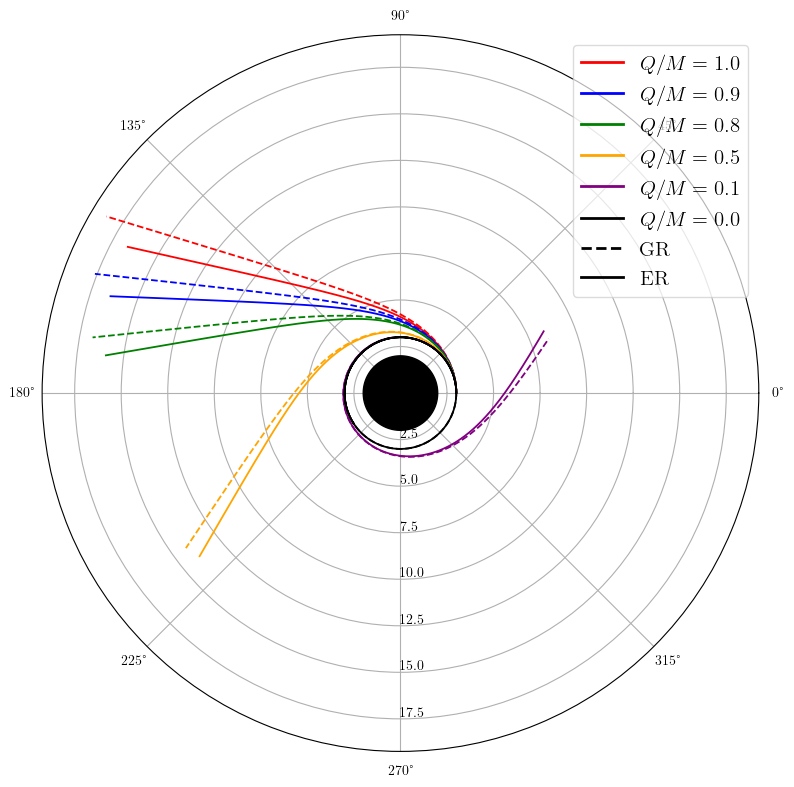

In [6]:
# ── Parameters ────────────────────────────────────────────────────────────────
# Format: (M, Q, color, label)
cases = [
    (1.0, 1.0, 'red',    r'$Q/M = 1.0$'),
    (1.0, 0.9, 'blue',   r'$Q/M = 0.9$'),
    (1.0, 0.8, 'green',  r'$Q/M = 0.8$'),
    (1.0, 0.5, 'orange', r'$Q/M = 0.5$'),
    (1.0, 0.1, 'purple', r'$Q/M = 0.1$'),
    (1.0, 0.0, 'black',  r'$Q/M = 0.0$'),
]

r0  = 3.0
kr  = 0
kph = 1

# ── Absorption event factory ───────────────────────────────────────────────────
# Must be a factory to avoid closure-over-loop-variable bug
def make_absorption_event(rp_val):
    def absorbed(lam, s):
        return s[1] - rp_val * 1.005   # stop just outside horizon
    absorbed.terminal  = True
    absorbed.direction = -1
    return absorbed

# ── Solver ────────────────────────────────────────────────────────────────────
def solve_geodesic(G_num, g_num, rpm_func, M_val, Q_val, kr, kph,
                   r0=20.0, lam_max=10, n_pts=20000):
    x0 = np.array([0.0, r0, np.pi/2, 0.0])
    kt = fix_kt(x0, kr, 0.0, kph, g_num, M_val, Q_val)
    k0 = np.array([kt, kr, 0.0, kph])

    rp, _ = rpm_func(M_val, Q_val)
    event = make_absorption_event(float(rp))

    sol = solve_ivp(
        fun=lambda lam, s: geodesic_rhs(lam, s, G_num, M_val, Q_val),
        t_span=(0, lam_max),
        y0=np.concatenate([x0, k0]),
        t_eval=np.linspace(0, lam_max, n_pts),
        method="DOP853",
        rtol=1e-10, atol=1e-12,
        events=event,
    )
    return sol

# ── Plot (single panel) ───────────────────────────────────────
theories = [
    ("GR", G_num_GR, g_num_GR, rpm_GR, '--'),
    ("ER", G_num_ER, g_num_ER, rpm_ER, '-'),
]

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 8))
ax.set_rlabel_position(270)

# ── Draw central black hole ───────────────────────────────────
rp_max = float(rpm_GR(1.0, 0.0)[0])
theta = np.linspace(0, 2*np.pi, 500)
ax.fill(theta, np.full_like(theta, rp_max), color='black', zorder=5)

# ── Integrate and plot (NO labels) ────────────────────────────
for M_val, Q_val, color, label in cases:
    for theory_name, G_num, g_num, rpm_func, linestyle in theories:

        sol = solve_geodesic(G_num, g_num, rpm_func,
                             M_val, Q_val, kr, kph, r0=r0)

        ax.plot(sol.y[3], sol.y[1],
                color=color, lw=1.3, linestyle=linestyle,
                zorder=4)

        if sol.status == 1:
            ax.plot(sol.y[3, -1], sol.y[1, -1],
                    'x', color=color, ms=6, zorder=6)

        residuals = check_normalization(sol, g_num, M_val, Q_val, target=0.0)
        print(f"{theory_name}, Q={Q_val}, Max normalization drift: {np.max(np.abs(residuals)):.2e}")

# ── Custom legend ─────────────────────────────────────────────

# Color legend (Q values)
color_handles = [
    Line2D([0], [0], color=c, lw=2, label=lbl)
    for _, _, c, lbl in cases
]

# Linestyle legend (theories)
style_handles = [
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='GR'),
    Line2D([0], [0], color='black', lw=2, linestyle='-', label='ER')
]

# Option 1: single combined legend
ax.legend(handles=color_handles + style_handles,
          loc="upper right", fontsize=15, framealpha=0.7)

# ── Final layout ─────────────────────────────────────────────
plt.tight_layout()
plt.savefig("images/NullGeodesics.png", dpi=150, bbox_inches='tight')
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_24116/2384784914.py:13: SyntaxWarning: invalid escape sequence '\m'
  f"{theory_name}: $\mu={mean:.2e}$, $\sigma={std:.2e}$"
/tmp/ipykernel_24116/2384784914.py:13: SyntaxWarning: invalid escape sequence '\s'
  f"{theory_name}: $\mu={mean:.2e}$, $\sigma={std:.2e}$"


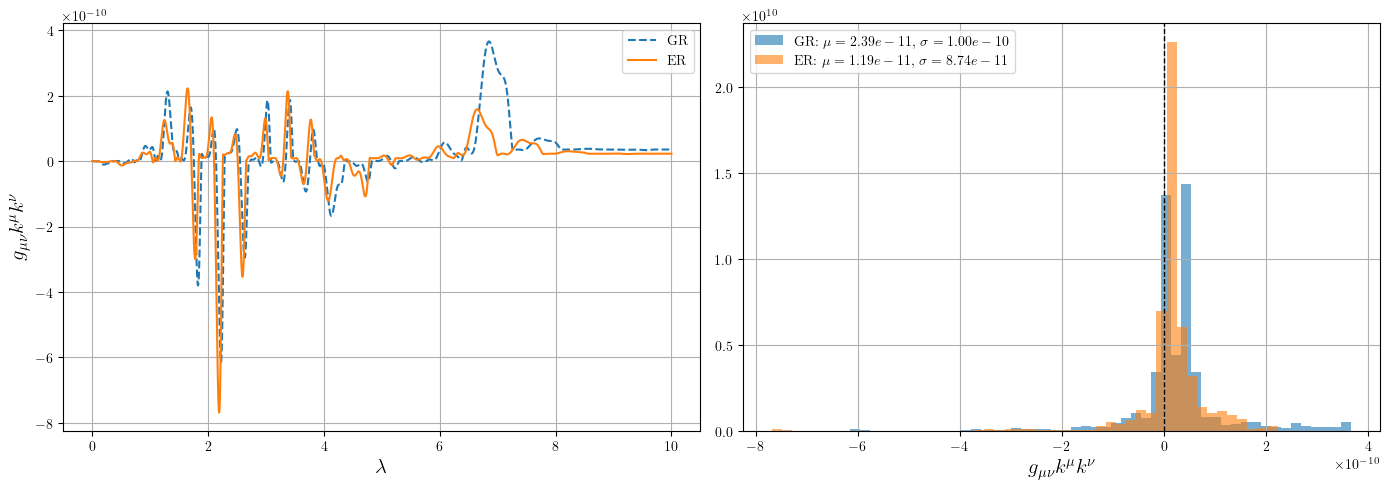

In [7]:
Q_norm = 0.5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for theory_name, G_num, g_num, rpm_func, linestyle in theories:
    sol = solve_geodesic(G_num, g_num, rpm_func, 1.0, Q_norm, kr, kph, r0=r0)
    residuals = check_normalization(sol, g_num, 1.0, Q_norm, target=0.0)

    mean, std = np.mean(residuals), np.std(residuals)

    ax1.plot(sol.t, residuals, linestyle=linestyle, label=theory_name)

    ax2.hist(residuals, bins=50, alpha=0.6, density=True, label=(
        f"{theory_name}: $\mu={mean:.2e}$, $\sigma={std:.2e}$"
    ))

ax1.set_xlabel(r"$\lambda$", fontsize=15)
ax1.set_ylabel(r"$g_{\mu\nu}k^\mu k^\nu$", fontsize=15)
ax1.legend()
ax1.grid()

ax2.set_xlabel(r"$g_{\mu\nu}k^\mu k^\nu$", fontsize=15)
ax2.axvline(0, color='black', lw=1, linestyle='--')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

## 3 - Effective Potential Analysis

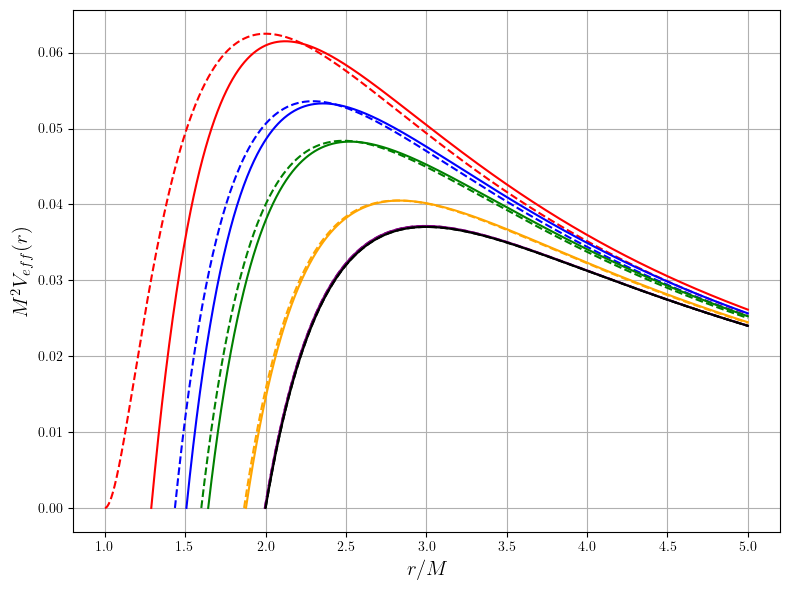

In [8]:
plt.figure(figsize=(8, 6))

for m, q, c, s in cases:
    rpGR = rpm_GR(m, q)[0]
    rpER = rpm_ER(m, q)[0]
    
    r_GR = np.linspace(rpGR, 5, 1000)
    r_ER = np.linspace(rpER, 5, 1000)
    
    Vgr = Veff_GR(r_GR, m, q)
    Ver = Veff_ER(r_ER, m, q)

    plt.plot(r_GR, Vgr, '--', color=c)
    plt.plot(r_ER, Ver, '-', color=c)

# --- Custom legend ---

# Color legend (Q values)
color_handles = [
    Line2D([0], [0], color=c, lw=2, label=s)
    for _, _, c, s in cases
]

# Linestyle legend (models)
style_handles = [
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='GR'),
    Line2D([0], [0], color='black', lw=2, linestyle='-', label='ER')
]

# Combine
handles = color_handles + style_handles

# plt.legend(handles=handles,loc="upper right", fontsize=10)

plt.grid()
plt.xlabel(r'$r/M$', fontsize=15)
plt.ylabel(r'$M^2 V_{eff}(r)$', fontsize=15)

plt.tight_layout()
plt.savefig("images/EffectivePotentials.png", dpi=150, bbox_inches='tight')
plt.show()